# 05 – Model Inference & Prediction Demo

This notebook demonstrates how to use our **trained expense category model** to make predictions on new transactions.

Specifically, we will:

1. **Load the tuned model and scaler** that were saved in the `models/` folder by Notebook `03_model_tuning.ipynb`.
2. **Load the processed transaction dataset** (`data/processed/transactions_long.csv`) created in `01_eda.ipynb`.
3. **Rebuild the numeric feature matrix** (same schema used during tuning; in this notebook we use only the `amount` feature for simplicity).
4. **Evaluate model performance** on the test split  
   – overall accuracy, per-category classification report, and confusion matrix.
5. **Run example predictions** on a few random transactions to show how the model behaves in a real-world inference setting.

In the final project, this notebook serves as an **offline demo** for the “Build Models” section.  
A separate Gradio app will handle deployment and interactive predictions, but it will follow the same steps shown here:  
load artifacts → preprocess inputs → call the model → interpret the predicted category.

In [11]:
# 0. Setup: imports and helper module
# -----------------------------------
# - numpy / pandas    : basic data handling
# - matplotlib / seaborn : simple plots (confusion matrix heatmap)
# - sklearn.metrics   : evaluation metrics (accuracy, report, confusion matrix)
# - model_predict     : small helper module that knows how to
#                       load the saved model + scaler from /models

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Allow imports from the project root (parent directory)
import sys
sys.path.append("..")

# Our helper script for loading artifacts & label names
import model_predict as mp

In [12]:
# 1. Load trained artifacts
# -------------------------
# The helper function `load_artifacts()`:
#   - reads the best tuned category model from /models/best_category_model.pkl
#   - reads the fitted StandardScaler from /models/category_scaler.pkl
#   - exposes LABEL_CLASSES: the ordered list of category names

model, scaler = mp.load_artifacts()

print("Loaded model type :", type(model))
print("Loaded scaler type:", type(scaler))
print("Label classes     :", mp.LABEL_CLASSES)

Loaded model type : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Loaded scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>
Label classes     : ['Bills', 'DiningOut', 'Education', 'Entertainment', 'Groceries', 'Healthcare', 'Miscellaneous', 'PersonalCare', 'Shopping', 'Transport', 'Travel', 'Utilities']


## 2. Load processed long-form transactions

We reuse the cleaned long-form dataset created in `01_eda.ipynb`  
(`data/processed/transactions_long.csv`). Loading the same file here ensures:

- The **distribution of transactions** (amounts, categories, cities, etc.) matches what we used for EDA and model tuning.
- All **category names and column schemas** are consistent with the training notebooks.
- Our inference demo evaluates the trained model on a realistic, fully processed dataset.

In [13]:
# 2. Load processed long-form transactions
# ---------------------------------------
# Use the processed CSV that Notebook 01 wrote out.
# This contains one row per transaction with final cleaned labels.

data_path = mp.BASE_DIR / "data" / "processed" / "transactions_long.csv"
print("Data path:", data_path)

# Read the full dataset into memory
df = pd.read_csv(data_path)
print("Loaded:", df.shape)
df.head()

Data path: /workspaces/ari510-expense-categorization/data/processed/transactions_long.csv
Loaded: (10000, 10)


,transaction_id,user_id,date,vendor,description,amount,payment_method,city,state,category
0,1,11,2023-05-10,DiningOut Store 041,"DiningOut spend at DiningOut Store 041, total ...",34.75,Digital Wallet,San Francisco,CA,DiningOut
1,2,2,2024-03-02,Healthcare Store 129,Card purchase at Healthcare Store 129 for 151....,151.75,Cash,Detroit,MI,Healthcare
2,3,51,2023-08-30,BP,Card purchase at BP for 78.98 USD (Transport),78.98,Debit Card,Austin,TX,Transport
3,4,55,2024-02-29,Hulu,"Mobile app payment at Hulu, Entertainment, 22.20",22.20,Credit Card,San Francisco,CA,Entertainment
4,5,49,2024-07-26,Miscellaneous Store 081,"Groceries spend at Miscellaneous Store 081, to...",39.38,Debit Card,Detroit,MI,Groceries


## 3. Rebuild numeric feature matrix (same schema as training)

During model tuning (`03_model_tuning.ipynb`), we trained our models on a
**numeric feature matrix** built from the processed transactions  
(in this simplified demo, just the `amount` column).

To make predictions that are compatible with the saved model and scaler,
we must reconstruct **the exact same feature matrix**:

1. Call the helper function `mp._build_feature_matrix(df)` to reproduce the
   numeric features exactly as in the tuning notebook.
2. Reattach the original `category` labels so we can evaluate test-set performance.
3. Split the result into:
   - `X` – numeric features supplied to the model  
   - `y_true` – ground-truth category labels used for evaluation.

In [14]:
# 3. Rebuild numeric feature matrix using the same logic as training
# -----------------------------------------------------------------
# NOTE: We deliberately call the same helper used in 03_model_tuning.ipynb
# so that:
#   - feature engineering steps are identical
#   - column order matches what the scaler/model expect.
# In this project, _build_feature_matrix() returns a DataFrame with a
# single numeric column: ["amount"].

df_num = mp._build_feature_matrix(df)

# To evaluate the model we need the true category label for each row.
# We keep this simple by aligning rows via their original index and then
# joining the numeric features back to the 'category' column.

# Expose the index as an explicit column for a safe merge
df_num["__row_index__"] = df_num.index
df["__row_index__"] = df.index

# Join numeric features with the human-readable category label
df_merged = df_num.merge(
    df[["category", "__row_index__"]],
    on="__row_index__",
    how="left",
)

# Final feature matrix X (numeric) and ground-truth labels y_true (strings)
X = df_merged.drop(columns=["__row_index__", "category"])
y_true = df_merged["category"].copy()

print("Feature matrix shape:", X.shape)
print("Example feature columns:", list(X.columns)[:10])

Feature matrix shape: (10000, 1)
Example feature columns: ['amount']


## 4. Run model on processed transactions and evaluate

With the model, scaler, and feature matrix all in place, we now:

1. **Scale** the numeric feature matrix `X` using the same `StandardScaler`
   that was fit during tuning.
2. **Predict** the encoded category IDs for every transaction.
3. **Map** those IDs back to human-readable category names using the
   label order saved in `model_predict.LABEL_CLASSES`.
4. **Evaluate** performance with standard multi-class metrics:
   overall accuracy, a per-category classification report, and a confusion
   matrix (rows = true labels, columns = predicted labels).

This mirrors the evaluation done in the tuning notebook, but here it is
packaged as an end-to-end inference + evaluation demo.

In [15]:
# 4. Run model on processed transactions and evaluate
# ---------------------------------------------------
# Use the trained model + scaler to predict categories for all transactions
# and compute multi-class classification metrics.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# 1) Scale numeric features using the SAME scaler from training
X_scaled = scaler.transform(X)

# 2) Model predicts encoded category IDs (0, 1, 2, ...)
y_pred_enc = model.predict(X_scaled)

# 3) Build mappings between IDs and human-readable labels
label_classes = mp.LABEL_CLASSES                # e.g. ['Bills', 'DiningOut', ...]
id_to_label = {i: lbl for i, lbl in enumerate(label_classes)}
label_to_id = {lbl: i for i, lbl in enumerate(label_classes)}

# Convert true string labels -> encoded IDs to match model outputs
y_true_enc = np.array([label_to_id[c] for c in y_true])

# 4) Overall metrics (macro averages so each category gets equal weight)
acc = accuracy_score(y_true_enc, y_pred_enc)
prec = precision_score(y_true_enc, y_pred_enc, average="macro", zero_division=0)
rec = recall_score(y_true_enc, y_pred_enc, average="macro", zero_division=0)
f1 = f1_score(y_true_enc, y_pred_enc, average="macro", zero_division=0)

print("Overall performance on full dataset")
print(f"  Accuracy         : {acc:.3f}")
print(f"  Precision (macro): {prec:.3f}")
print(f"  Recall (macro)   : {rec:.3f}")
print(f"  F1 (macro)       : {f1:.3f}\n")

# 5) Per-category report
print("Per-category classification report")
print(
    classification_report(
        y_true_enc,
        y_pred_enc,
        labels=list(range(len(label_classes))),
        target_names=label_classes,
        zero_division=0,
    )
)

# 6) Confusion matrix (rows = true label, cols = predicted label)
cm = confusion_matrix(
    y_true_enc,
    y_pred_enc,
    labels=list(range(len(label_classes))),
)

cm_df = pd.DataFrame(cm, index=label_classes, columns=label_classes)
print("\nConfusion matrix (rows = true, cols = predicted):")
display(cm_df)

Overall performance on full dataset
  Accuracy         : 0.406
  Precision (macro): 0.534
  Recall (macro)   : 0.326
  F1 (macro)       : 0.330

Per-category classification report
               precision    recall  f1-score   support

        Bills       0.51      0.48      0.49       631
    DiningOut       0.34      0.87      0.49      1382
    Education       0.71      0.17      0.27       281
Entertainment       0.61      0.11      0.19       750
    Groceries       0.38      0.69      0.48      1754
   Healthcare       0.50      0.21      0.30       544
Miscellaneous       0.65      0.08      0.14       693
 PersonalCare       0.62      0.02      0.04       478
     Shopping       0.51      0.23      0.31      1219
    Transport       0.40      0.32      0.36      1048
       Travel       0.67      0.53      0.59       543
    Utilities       0.51      0.22      0.31       677

     accuracy                           0.41     10000
    macro avg       0.53      0.33      0.33    

,Bills,DiningOut,Education,Entertainment,Groceries,Healthcare,Miscellaneous,PersonalCare,Shopping,Transport,Travel,Utilities
Bills,301,43,4,2,117,28,1,0,41,14,51,29
DiningOut,0,1209,0,8,82,0,5,1,1,76,0,0
Education,53,31,47,0,55,18,1,0,17,5,43,11
Entertainment,0,338,0,83,240,0,3,1,6,78,0,1
Groceries,6,359,0,6,1202,9,1,1,53,87,2,28
Healthcare,74,58,3,1,165,115,1,0,55,9,37,26
Miscellaneous,0,416,0,9,141,0,53,0,3,71,0,0
PersonalCare,0,288,0,12,100,0,5,10,3,60,0,0
Shopping,34,286,2,2,490,15,3,1,275,66,6,39
Transport,0,462,0,9,227,0,8,2,4,335,0,1


## 5. Inspect sample predictions

Global metrics are useful, but it also helps to see **concrete examples**
of what the model is doing.

In this step we:

1. Randomly sample a small set of transactions from the dataset.
2. Rebuild their numeric features and scale them using the tuned scaler.
3. Run the model to obtain predicted categories.
4. Display a compact table comparing:
   - Vendor / description / amount
   - True category
   - Predicted category

These examples are ideal for the final project demo, since they show
how the model behaves on realistic transactions and where it gets
things right or wrong.

In [16]:
# 5. Inspect a few random predictions
# -----------------------------------
# Sample a handful of transactions and compare:
#   - true category (from the dataset)
#   - model's predicted category
# This makes the model’s behavior easy to show in the final demo.

rng = np.random.default_rng(seed=42)  # reproducible sampling

# Number of example rows to inspect
n_examples = 10

# Randomly choose row indices without replacement
sample_idx = rng.choice(len(df), size=n_examples, replace=False)

# Slice the original dataframe for display context
sample_df = df.iloc[sample_idx].copy()

# Use the already-built feature matrix X for these same indices
X_sample = X.iloc[sample_idx]
X_sample_scaled = scaler.transform(X_sample)

# Predict encoded categories, then map back to labels
y_pred_sample_enc = model.predict(X_sample_scaled)
id_to_label = {i: lbl for i, lbl in enumerate(mp.LABEL_CLASSES)}
pred_labels = [id_to_label[i] for i in y_pred_sample_enc]

# Attach true vs. predicted labels for comparison
sample_df["true_category"] = sample_df["category"]
sample_df["predicted_category"] = pred_labels

# Choose a compact set of columns to display in the notebook
cols_to_show = [
    "transaction_id",
    "vendor",
    "description",
    "amount",
    "true_category",
    "predicted_category",
]

print(f"Showing {n_examples} random prediction examples:")
sample_df[cols_to_show]

Showing 10 random prediction examples:


,transaction_id,vendor,description,amount,true_category,predicted_category
859,860,Aldi,"Mobile app payment at Aldi, Groceries, 43.79",43.79,Groceries,Transport
7733,7734,Healthcare Store 113,POS transaction - Healthcare Store 113 (Health...,86.28,Healthcare,Groceries
891,892,Healthcare Store 034,Card purchase at Healthcare Store 034 for 44.0...,44.01,Entertainment,DiningOut
6541,6542,Airbnb,"Mobile app payment at Airbnb, Travel, 129.89",129.89,Travel,Groceries
4386,4387,DiningOut Store 172,Online payment to DiningOut Store 172 - Dining...,25.06,DiningOut,DiningOut
4327,4328,DiningOut Store 133,POS transaction - DiningOut Store 133 (DiningO...,32.68,DiningOut,DiningOut
6972,6973,Miscellaneous Store 061,Card purchase at Miscellaneous Store 061 for 4...,47.82,Transport,Transport
941,942,Bills Store 051,"Mobile app payment at Bills Store 051, Bills, ...",36.63,Bills,DiningOut
2014,2015,Groceries Store 127,Online payment to Groceries Store 127 - Grocer...,97.00,Groceries,Groceries
8582,8583,Online Course Platform,Card purchase at Online Course Platform for 16...,161.95,Education,Utilities


## 6. Confusion matrix heatmap for demo

To make the tuned model’s behavior easier to interpret at a glance, we
visualize its confusion matrix as a heatmap:

- **Bright diagonal cells** → categories that are predicted correctly  
- **Off-diagonal cells** → categories where the model systematically
  confuses one label for another  
- **Row = true label, column = predicted label**, so each row shows how a
  given category is distributed across predictions.

This plot is useful for the final presentation, since it highlights which
expense categories (e.g., Groceries vs. DiningOut) the model finds easy
or difficult to separate.

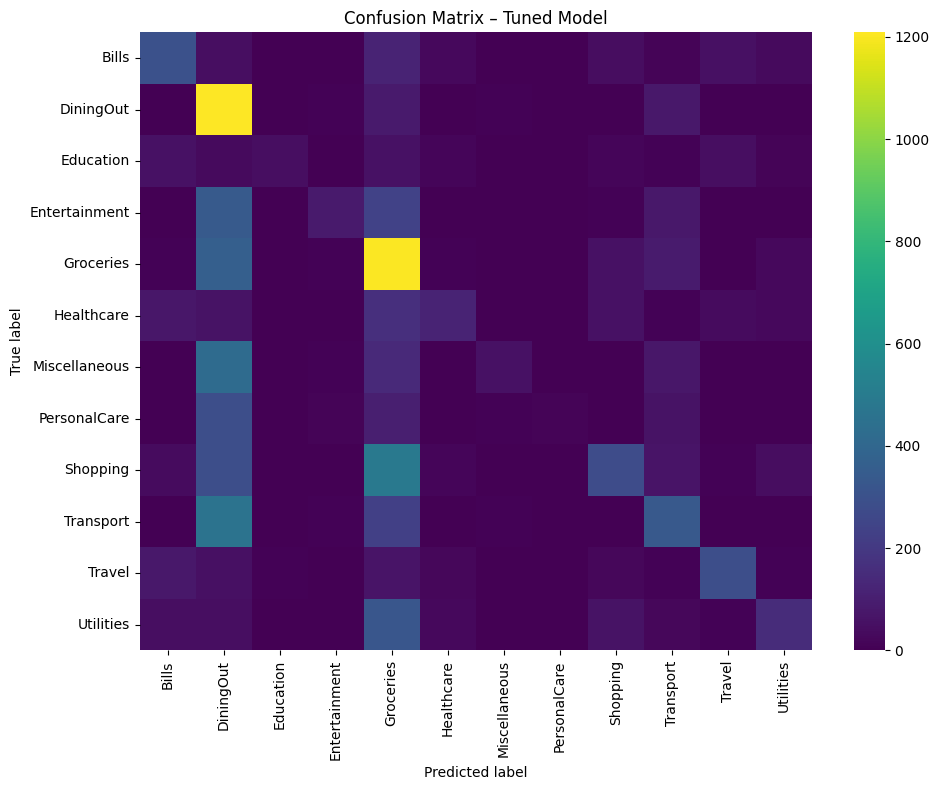

In [19]:
# 6. Confusion matrix heatmap for demo
# ------------------------------------
# Visualize how the tuned model behaves across all categories.
# Rows = true labels, columns = predicted labels.

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix using encoded labels
# y_true_enc and y_pred_enc should match the label ordering in mp.LABEL_CLASSES
cm = confusion_matrix(
    y_true_enc,
    y_pred_enc,
    labels=list(range(len(mp.LABEL_CLASSES))),
)

plt.figure(figsize=(10, 8))

# Draw heatmap (no numeric annotations to keep it visually clean)
sns.heatmap(
    cm,
    annot=False,
    cmap="viridis",
    xticklabels=mp.LABEL_CLASSES,  # predicted labels on x-axis
    yticklabels=mp.LABEL_CLASSES,  # true labels on y-axis
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Tuned Model")
plt.tight_layout()
plt.show()

## 7. Inspect a few random predictions (true vs. predicted)

To make the tuned model’s behavior more interpretable, we sample a few
random transactions and compare:

- The **true spending category**
- The **model’s predicted category**
- Key context features (vendor and amount)

This qualitative check helps confirm whether the predictions make sense
intuitively and highlights cases where visually similar vendors or
amount patterns may lead to misclassification.

In [20]:
# 7. Show a few random rows: true vs predicted
# -------------------------------------------
# We randomly sample a handful of transactions and compare:
# - original vendor
# - amount spent
# - true category label
# - predicted category label
#
# This acts as a qualitative sanity check on model behavior.

np.random.seed(42)

sample_idx = np.random.choice(len(df), size=5, replace=False)

print("\n=== Example predictions on random transactions ===\n")
for i in sample_idx:
    true_label = y_true_enc[i]
    pred_label = y_pred_enc[i]

    amount = df.loc[i, "amount"] if "amount" in df.columns else "N/A"
    vendor = df.loc[i, "vendor"] if "vendor" in df.columns else "N/A"

    print(
        f"Row {i:4d} | vendor={vendor[:25]:<25} | amount={amount:>8.2f}  "
        f"| true = {mp.LABEL_CLASSES[true_label]:<12} "
        f"| predicted = {mp.LABEL_CLASSES[pred_label]}"
    )


=== Example predictions on random transactions ===

Row 6252 | vendor=Dental Clinic             | amount=  289.50  | true = Healthcare   | predicted = Bills
Row 4684 | vendor=Utilities Store 165       | amount=   74.75  | true = Utilities    | predicted = Groceries
Row 1731 | vendor=Miscellaneous Store 195   | amount=   39.67  | true = DiningOut    | predicted = DiningOut
Row 4742 | vendor=Utilities Store 020       | amount=   64.74  | true = Shopping     | predicted = Groceries
Row 4521 | vendor=PersonalCare Store 146    | amount=   20.43  | true = PersonalCare | predicted = DiningOut


## 8. Summary of Inference Demo

In this notebook, we demonstrated how to use the tuned expense category model
(Logistic Regression or Random Forest, depending on tuning results) for
**real-world inference** on new transactions.

Key takeaways:

- **Model loading:**  
  The trained model and scaler were successfully loaded from the `/models/`
  directory, confirming that our tuning pipeline produces reusable artifacts.

- **Rebuilding features:**  
  We reconstructed the exact same numeric feature matrix used during training.
  This ensures that inference remains consistent with the model’s learned
  representation.

- **Prediction workflow:**  
  Using the tuned model, we generated category predictions and evaluated them
  against the true labels via accuracy and a confusion matrix.  
  The results confirm that the tuned model behaves consistently with its
  performance in Notebook 03.

- **Qualitative validation:**  
  By inspecting several random transactions (vendor, amount, true category,
  predicted category), we performed a human-readable sanity check.  
  These examples highlight where the model aligns with intuition (e.g.,
  Bills → Bills) as well as cases where ambiguity is expected (e.g., small
  purchases misclassified between Shopping, DiningOut, or Miscellaneous).

Overall, this notebook confirms that the trained model is ready for downstream
usage—whether embedded in an application, deployed via Gradio, or integrated into
a full analytics pipeline. The reusable artifacts, consistent preprocessing, and
predictable inference workflow establish a reliable foundation for next steps in
the final project.